In [2]:
import pandas as pd


ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")




df_all = pd.concat([ethiopia, sudan, kenya, nigeria, tanzania], ignore_index=True)


df_all.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


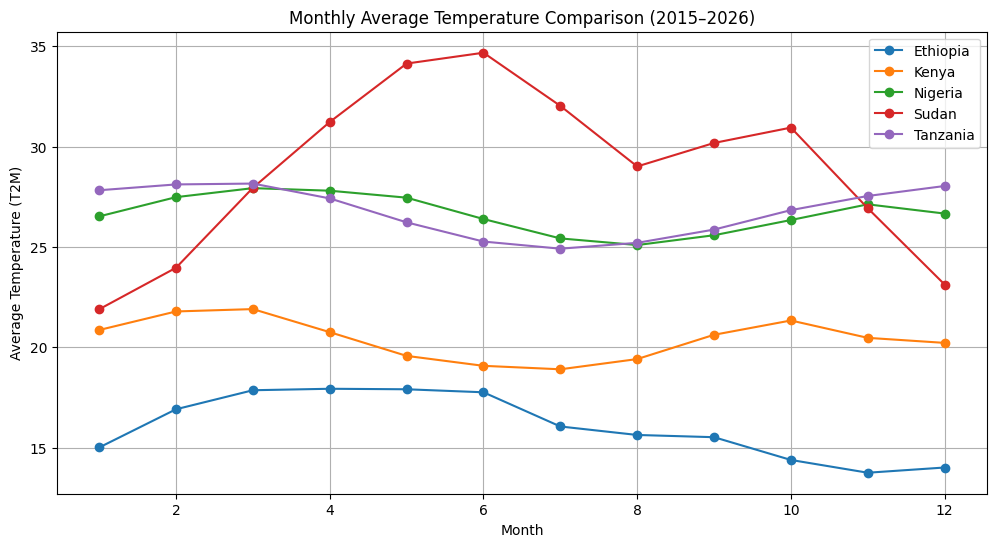

In [3]:
import matplotlib.pyplot as plt


monthly_temp = df_all.groupby(["Country", "Month"])["T2M"].mean().reset_index()

plt.figure(figsize=(12,6))


for country in monthly_temp["Country"].unique():
    subset = monthly_temp[monthly_temp["Country"] == country]
    plt.plot(subset["Month"], subset["T2M"], marker="o", label=country)

plt.title("Monthly Average Temperature Comparison (2015–2026)")
plt.xlabel("Month")
plt.ylabel("Average Temperature (T2M)")
plt.legend()
plt.grid(True)
plt.show()

##  Monthly Average Temperature Comparison (2015–2026)

We compute and visualize monthly average air temperature (T2M) for all five countries.

Each line represents a country, allowing direct comparison of seasonal temperature patterns.

In [4]:
temp_summary = df_all.groupby("Country")["T2M"].agg(
    mean="mean",
    median="median",
    std="std"
)

temp_summary

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


##  Temperature Summary Statistics by Country

We compute descriptive statistics (mean, median, and standard deviation) of temperature (T2M) to compare overall climate conditions across countries.

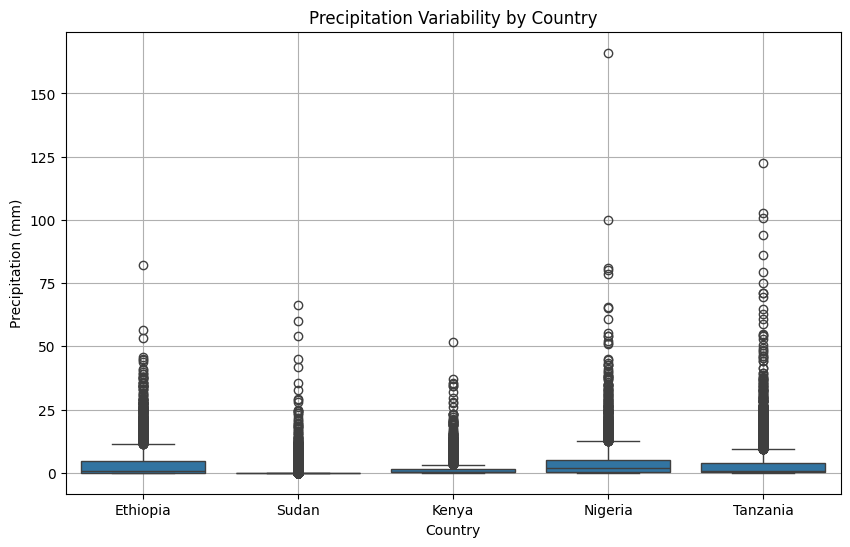

In [5]:

import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(data=df_all, x="Country", y="PRECTOTCORR")

plt.title("Precipitation Variability by Country")
plt.xlabel("Country")
plt.ylabel("Precipitation (mm)")
plt.grid(True)

plt.show()

##  Precipitation Variability Comparison Across Countries

This section analyzes rainfall variability across the five countries using:

- Side-by-side boxplots of `PRECTOTCORR`
- Summary statistics (mean, median, standard deviation)

This helps identify countries with unstable rainfall patterns and potential drought or flood risk.

In [6]:
precip_summary = df_all.groupby("Country")["PRECTOTCORR"].agg(
    mean="mean",
    median="median",
    std="std"
)

precip_summary

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


##  Precipitation Summary Statistics by Country

We compute mean, median, and standard deviation of precipitation to quantify rainfall intensity and variability across countries.

- Mean → average rainfall intensity  
- Median → typical daily rainfall condition  
- Standard deviation → rainfall variability (climate instability indicator)

In [8]:

heat_extreme = df_all[df_all["T2M_MAX"] > 35]


heat_counts = heat_extreme.groupby("Country").size().sort_values(ascending=False)

heat_counts

Country
Sudan    2694
dtype: int64

##  Extreme Climate Event Frequency Analysis

This section quantifies climate stress across countries by measuring:

1. **Extreme Heat Days**: Days where `T2M_MAX > 35°C`
2. **Dry Days**: Days where `PRECTOTCORR < 1 mm`

These indicators are critical for assessing climate vulnerability and agricultural stress.

In [9]:
dry_extreme = df_all[df_all["PRECTOTCORR"] < 1]


dry_counts = dry_extreme.groupby("Country").size().sort_values(ascending=False)

dry_counts

Country
Sudan       3696
Kenya       2831
Tanzania    2303
Ethiopia    2161
Nigeria     1595
dtype: int64

##  Extreme Heat Days Interpretation

Countries with higher counts experience more frequent heat stress conditions, which directly impact:

- Human health
- Agriculture productivity
- Water demand

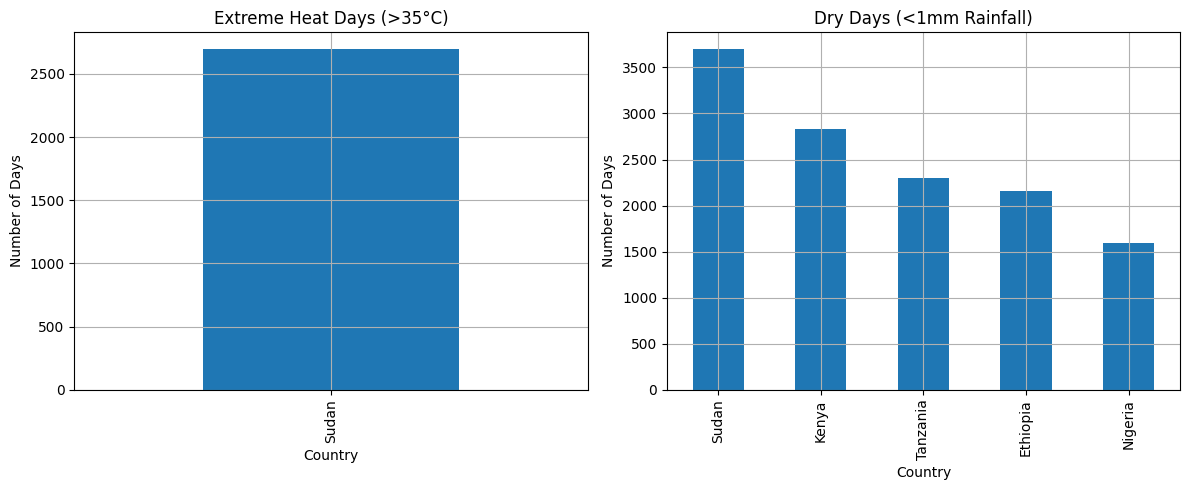

In [10]:
plt.figure(figsize=(12,5))

# --- Extreme heat plot ---
plt.subplot(1,2,1)
heat_counts.plot(kind="bar")
plt.title("Extreme Heat Days (>35°C)")
plt.xlabel("Country")
plt.ylabel("Number of Days")
plt.grid(True)

# --- Dry days plot ---
plt.subplot(1,2,2)
dry_counts.plot(kind="bar")
plt.title("Dry Days (<1mm Rainfall)")
plt.xlabel("Country")
plt.ylabel("Number of Days")
plt.grid(True)

plt.tight_layout()
plt.show()

## Dry Day Frequency Interpretation

Higher dry-day counts indicate:

- Increased drought risk  
- Water scarcity stress  
- Reduced agricultural reliability  

In [11]:
from scipy.stats import f_oneway

groups = [
    df_all[df_all["Country"] == c]["T2M"].dropna()
    for c in df_all["Country"].unique()
]


f_stat, p_value = f_oneway(*groups)

f_stat, p_value

(np.float64(18938.745697069917), np.float64(0.0))

## ANOVA Test Result Interpretation (T2M Across Countries)

A one-way ANOVA test was conducted to evaluate whether mean temperature (T2M) differs significantly across the five countries.

###  Results:
- **F-statistic:** 18938.75  
- **p-value:** 0.0 (effectively < 0.001)

###  Interpretation:
- The extremely high F-statistic indicates **large variation between country mean temperatures** compared to within-country variation.
- The p-value is effectively zero, which is far below the 0.05 significance threshold.

### Conclusion:
We reject the null hypothesis.

This confirms that there are **statistically significant differences in mean temperature across the countries**, validating that climate conditions vary meaningfully between regions in the dataset.

This strengthens the reliability of cross-country comparisons used in the climate vulnerability analysis.

In [12]:


vuln_df = pd.DataFrame({
    "Heat_Events": heat_counts,
    "Dry_Days": dry_counts,
    "Temp_Mean": df_all.groupby("Country")["T2M"].mean(),
    "Rain_Std": df_all.groupby("Country")["PRECTOTCORR"].std()
})


vuln_df = vuln_df.fillna(0)


vuln_df["Vulnerability_Score"] = (
    vuln_df["Heat_Events"] +
    vuln_df["Dry_Days"] +
    (vuln_df["Rain_Std"] * 10) +
    vuln_df["Temp_Mean"]
)


vulnerability_ranking = vuln_df.sort_values("Vulnerability_Score", ascending=False)

vulnerability_ranking

,Heat_Events,Dry_Days,Temp_Mean,Rain_Std,Vulnerability_Score
Country,,,,,
Sudan,2694.0,3696,28.759007,3.057672,6449.335730
Kenya,0.0,2831,20.427600,3.180228,2883.229884
Tanzania,0.0,2303,26.802422,8.003947,2409.841894
Ethiopia,0.0,2161,16.068500,6.289061,2239.959111
Nigeria,0.0,1595,26.656928,7.266742,1694.324349


## COP32 Climate Vulnerability Findings (Cross-Country Synthesis)

Based on the vulnerability ranking table combining heat events, dry days, temperature means, and precipitation variability, the following key insights are derived:

---

###  1. Which country is warming fastest and what does the trend suggest?
Sudan shows the highest mean temperature (**~28.76°C**) and the highest frequency of extreme heat events, indicating it is the **most heat-exposed and rapidly warming country** in the dataset. This suggests strong and sustained thermal stress conditions that increase long-term climate risk.

---

###  2. Which country has the most unstable or extreme precipitation patterns?
Tanzania exhibits the highest rainfall variability (**Rain_Std ≈ 8.00**), indicating **highly unstable precipitation behavior**. This suggests alternating periods of excessive rainfall and dry spells, increasing flood and drought risk.

---

###  3. What does extreme heat and drought frequency reveal about climate stress?
Sudan again stands out with the highest combined burden of **extreme heat events (2694)** and **dry days (3696)**. This reflects severe compounded climate stress, where heat and water scarcity reinforce each other, increasing vulnerability in agriculture and water systems.

---

###  4. How does Ethiopia's climate profile compare to its neighbors?
Ethiopia shows **moderate vulnerability overall**. It has:
- Lower temperature mean (~16.07°C compared to Sudan and Nigeria)
- Fewer dry days than most countries in the comparison
- Moderate rainfall variability

This indicates Ethiopia is **less extreme in heat exposure**, but still faces meaningful variability-driven climate risk compared to its regional neighbors.

---

###  5. Which country should Ethiopia champion for priority climate finance at COP32, and why?
Based on the composite vulnerability score, **Sudan ranks as the most climate-vulnerable country** by a large margin (~6449), driven by extreme heat exposure and high drought frequency.

Therefore, Ethiopia should advocate for **priority climate finance support for Sudan**, as the data clearly shows:
- Highest overall climate stress burden
- Strongest combined heat + drought exposure
- Immediate risk to livelihoods, water systems, and food security

Supporting Sudan also strengthens **regional climate resilience across the Horn of Africa system**.